# 🧬 Introduction to DataFrames & Single-Cell Data (Scanpy)
## Goals
- Understand what a dataframe is
- Learn rows, columns, and data types
- Load and explore single-cell data
- Get familiar with AnnData (Scanpy)

### Before doing anything, we first need to Install the pre-requisite software and download data

In [ ]:
# install scanpy
%pip install scanpy
# clone the repository so that we have all the data and notebooks ready to go
!git clone https://github.com/tuonglab/FIMSA-training-workshop-1.git

fatal: destination path 'FIMSA-training-workshop-1' already exists and is not an empty directory.


## What is a DataFrame?

A DataFrame is a table-like structure:
- Rows = observations (e.g. cells)
- Columns = features (e.g. genes or metadata)

Think of it like an Excel spreadsheet.

In [ ]:
import pandas as pd

df = pd.DataFrame({
    "cell_id": ["cell1", "cell2", "cell3"],
    "gene_count": [1000, 1500, 900],
    "cell_type": ["T cell", "B cell", "Monocyte"]
})

df

,cell_id,gene_count,cell_type
0,cell1,1000,T cell
1,cell2,1500,B cell
2,cell3,900,Monocyte


## What does `.` mean in Python?

In Python, the dot (`.`) is used to access **attributes** and **functions** that belong to an object.

Think of it like:
> "go inside this object and get something"

if the text after the (`.`) has a parentheses, it is a function, otherwise it is an attribute


### We can practice using this (`.`) when inspecting a Dataframe

In [ ]:
df.head()
df.shape
df.columns
df.dtypes

,0
cell_id,object
gene_count,int64
cell_type,object


## Common Data Types
- int: whole numbers
- float: decimals
- object/string: text
- category: categorical labels

In [ ]:
df["cell_type"] = df["cell_type"].astype("category")
df.dtypes

,0
cell_id,object
gene_count,int64
cell_type,category


## From DataFrames to Single-Cell Data

Single-cell datasets:
- Large (thousands of cells)
- Sparse
- Stored in AnnData

.X = expression matrix
.obs = cell metadata
.var = gene metadata

In [ ]:
import scanpy as sc

adata = sc.read_h5ad("/content/FIMSA-training-workshop-1/data/example_adata.h5ad")
adata

AnnData object with n_obs × n_vars = 3000 × 33538
    obs: 'n_counts', 'n_genes', 'file', 'mito', 'doublet_scores', 'predicted_doublets', 'old_annotation_uniform', 'organ', 'Sort_id', 'age', 'method', 'donor', 'sex', 'Sample', 'scvi_clusters', 'is_maternal_contaminant', 'anno_lvl_2_final_clean', 'celltype_annotation'
    var: 'GeneID', 'GeneName', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'scvi_model_var'
    uns: 'leiden', 'scvi', 'umap'
    obsm: 'X_scvi', 'X_umap'
    obsp: 'scvi_connectivities', 'scvi_distances'

## Exploring AnnData

In [ ]:
adata.shape
adata.obs.head()
adata.var.head()

,GeneID,GeneName,highly_variable,means,dispersions,dispersions_norm,scvi_model_var
TSPAN6,ENSG00000000003,TSPAN6,False,1.491209,3.248330,0.032086,False
TNMD,ENSG00000000005,TNMD,True,0.862094,5.003802,3.086971,True
DPM1,ENSG00000000419,DPM1,False,1.749417,2.963759,-0.564548,False
SCYL3,ENSG00000000457,SCYL3,False,0.514126,2.997290,-0.382284,False
C1orf112,ENSG00000000460,C1orf112,False,0.562297,2.849392,-0.603232,False


## Key Idea
- adata.obs = cells (like DataFrame)
- adata.var = genes (like DataFrame)

In [ ]:
type(adata.obs)
type(adata.var)

pandas.core.frame.DataFrame

## Simple Filtering Example

In [ ]:
if "n_genes" in adata.obs.columns:
    filtered = adata[adata.obs["n_genes"] > 1000]
filtered

View of AnnData object with n_obs × n_vars = 2798 × 33538
    obs: 'n_counts', 'n_genes', 'file', 'mito', 'doublet_scores', 'predicted_doublets', 'old_annotation_uniform', 'organ', 'Sort_id', 'age', 'method', 'donor', 'sex', 'Sample', 'scvi_clusters', 'is_maternal_contaminant', 'anno_lvl_2_final_clean', 'celltype_annotation'
    var: 'GeneID', 'GeneName', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'scvi_model_var'
    uns: 'leiden', 'scvi', 'umap'
    obsm: 'X_scvi', 'X_umap'
    obsp: 'scvi_connectivities', 'scvi_distances'

## Quick Visualization

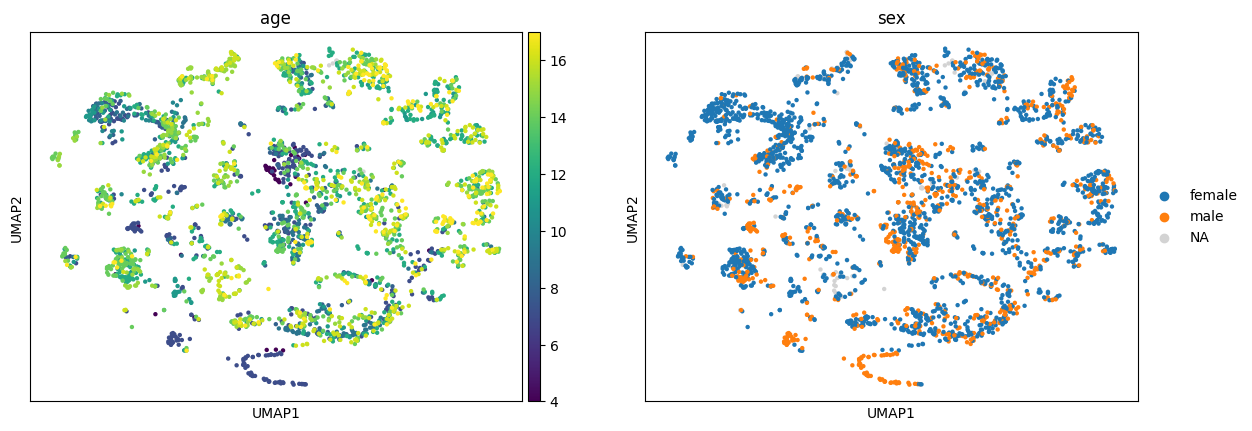

In [ ]:
sc.pl.umap(
    adata,
    color=["age", "sex"]
)

## Summary
- DataFrames store tabular data
- Rows = cells, Columns = features
- AnnData extends DataFrames for single-cell data
- .obs and .var are key